<a href="https://colab.research.google.com/github/IshaanMhalgi1/mlassignments/blob/main/ass11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 11

11. Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.

Data Set: https://www.kaggle.com/mohansacharya/graduate-admissions

The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.

Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

Importing dataset

In [ ]:
df = pd.read_csv('/content/Admission_Predict.csv')
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


Data cleaning

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


df.columns = df.columns.str.strip()

print("\nColumns after cleaning:\n", df.columns)


df['Admitted'] = df['Chance of Admit'].apply(lambda x: 1 if x >= 0.75 else 0)

df = df.drop('Chance of Admit', axis=1)

print("\nProcessed Data:\n", df.head())


Missing Values:
 Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

Columns after cleaning:
 Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')

Processed Data:
    Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   Research  Admitted  
0         1         1  
1         1         1  
2         1         0  
3         1 

Scaling the data

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Admitted', axis=1)
y = df['Admitted']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Random train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


Decision Tree Model fitting

In [ ]:
model = DecisionTreeClassifier(criterion='gini', random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy metrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8625

Confusion Matrix:
 [[39  8]
 [ 3 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.88        47
           1       0.79      0.91      0.85        33

    accuracy                           0.86        80
   macro avg       0.86      0.87      0.86        80
weighted avg       0.87      0.86      0.86        80



Heatmap of Confusion matrix

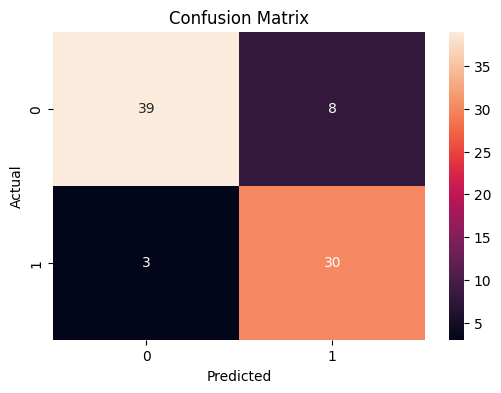

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

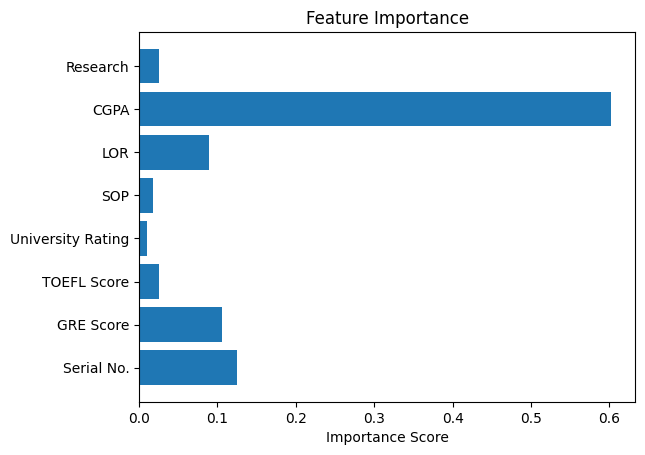

In [ ]:
importances = model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()